This notebook compares 8 models:

- Base HMM
- Stay
- Stay + Turn
- Stay + Spatial
- Leaf
- Leaf + Stay
- Leaf + Stay + Turn
- Leaf + Stay + Spatial

In [1]:
println("$(Threads.nthreads()) Threads")
if Threads.nthreads() == 1
    println("Not running in parallel")
end

8 Threads


In [34]:
# Whether to recompute results
RERUN = false

false

In [35]:
using StatsPlots
using FileIO
using EM
filepath = ".."
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl")

/Users/ari/Dropbox/Princeton/Loren Frank Lab/SpatialBanditTask/notebooks


subject_cov (generic function with 1 method)

In [29]:
# fns = [
#     ("hmm", run_hmm_em),
#     ("hmm_stay", run_hmm_em_stay),
#     ("hmm_stay_turn", run_hmm_em_stay_turn),
#     ("hmm_stay_spatial", run_hmm_em_stay_spatial),
#     ("hmm_leaf", run_hmm_em_leaf),
#     ("hmm_leaf_stay", run_hmm_em_leaf_stay),
#     ("hmm_em_leaf_stay_turn", run_hmm_em_leaf_stay_turn),
#     ("hmm_leaf_stay_spatial", run_hmm_em_leaf_stay_spatial),
#     ]
fns_leaf = [
    ("hmm_leaf", run_hmm_leaf),
    # ("hmm_leaf_γ2", run_hmm_leaf_γ2),
    # ("hmm_leaf_retainbelief", run_hmm_leaf_retainbelief),
    ("hmm_leaf_stay", run_hmm_leaf_stay),
    ("hmm_leaf_stay_γ2", run_hmm_leaf_stay_γ2),
    ("hmm_leaf_stay_retainbelief", run_hmm_leaf_stay_retainbelief),
    ("hmm_leaf_stay_turn", run_hmm_leaf_stay_turn),
    ("hmm_leaf_stay_spatial", run_hmm_leaf_stay_spatial),
    ]
# fns_nonleaf = [
#     ("hmm", run_hmm),
#     ("hmm_stay", run_hmm_em_stay),
#     ("hmm_stay_turn", run_hmm_em_stay_turn),
#     ("hmm_stay_spatial", run_hmm_em_stay_spatial),
#     ]
fns_leafbias = [
    ("hmm_leaf_stay_turn_leafturn", run_hmm_leaf_stay_turn_leafturn),
    ("hmm_leaf_stay_turn_leafspatial", run_hmm_leaf_stay_turn_leafspatial),
    ("hmm_leaf_stay_spatial_leafturn", run_hmm_leaf_stay_spatial_leafturn),
    ("hmm_leaf_stay_spatial_leafspatial", run_hmm_leaf_stay_spatial_leafspatial),
    ]

fns_leafbias_γ2 = [
    ("hmm_leaf_stay_turn_leafturn_γ2", run_hmm_leaf_stay_turn_leafturn_γ2),
    ("hmm_leaf_stay_turn_leafspatial_γ2", run_hmm_leaf_stay_turn_leafspatial_γ2),
    ("hmm_leaf_stay_spatial_leafturn_γ2", run_hmm_leaf_stay_spatial_leafturn_γ2),
    ("hmm_leaf_stay_spatial_leafspatial_γ2", run_hmm_leaf_stay_spatial_leafspatial_γ2),
    ]
fns = vcat(fns_leaf, fns_leafbias, fns_leafbias_γ2)
# fns = fns_leaf

14-element Vector{Tuple{String, Function}}:
 ("hmm_leaf", run_hmm_leaf)
 ("hmm_leaf_stay", run_hmm_leaf_stay)
 ("hmm_leaf_stay_γ2", run_hmm_leaf_stay_γ2)
 ("hmm_leaf_stay_retainbelief", run_hmm_leaf_stay_retainbelief)
 ("hmm_leaf_stay_turn", run_hmm_leaf_stay_turn)
 ("hmm_leaf_stay_spatial", run_hmm_leaf_stay_spatial)
 ("hmm_leaf_stay_turn_leafturn", run_hmm_leaf_stay_turn_leafturn)
 ("hmm_leaf_stay_turn_leafspatial", run_hmm_leaf_stay_turn_leafspatial)
 ("hmm_leaf_stay_spatial_leafturn", run_hmm_leaf_stay_spatial_leafturn)
 ("hmm_leaf_stay_spatial_leafspatial", run_hmm_leaf_stay_spatial_leafspatial)
 ("hmm_leaf_stay_turn_leafturn_γ2", run_hmm_leaf_stay_turn_leafturn_γ2)
 ("hmm_leaf_stay_turn_leafspatial_γ2", run_hmm_leaf_stay_turn_leafspatial_γ2)
 ("hmm_leaf_stay_spatial_leafturn_γ2", run_hmm_leaf_stay_spatial_leafturn_γ2)
 ("hmm_leaf_stay_spatial_leafspatial_γ2", run_hmm_leaf_stay_spatial_leafspatial_γ2)

In [36]:
if RERUN
    for animal in animals
        for (fname, fn) in fns_leafbias
            results = fn(load_animal(animal, filepath))
            save("$(filepath)/results/biases/$(fname)_$(animal).jld2", "$(fname)_$(animal)", results)
        end
    end
end

In [37]:
function load_results(animals, fns)
    results = Dict()
    aics = zeros(length(animals), length(fns))
    for (i, animal) in enumerate(animals)
        for (j, (fname, fn)) in enumerate(fns)
            filename = "$(filepath)/results/biases/$(fname)_$(animal).jld2"
            if (isfile(filename))
                results[(animal, fname)] = load(filename, "$(fname)_$(animal)")
                aics[i, j] = iaic(results[(animal, fname)])
            else
                println("Missing: $(filename)")
            end
        end
    end
    (results, aics)
end

load_results (generic function with 1 method)

First, let's take a look at the AICs across all compared functions.

It's pretty apparent that the models including some leaf choice bias (either `leafspatial` or `leafturn`) are *much* better than everything else

At right we're just showing the difference from baseline (no biases)

All model names are abbreviated down to 's(tay) + biases'

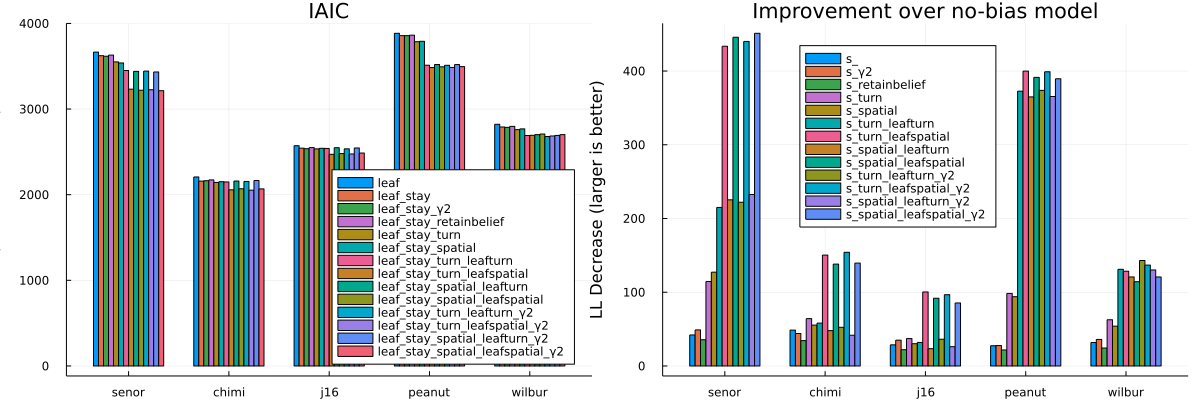

In [38]:
fns = vcat(fns_leaf, fns_leafbias, fns_leafbias_γ2)
(results, aics) = load_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][5:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][15:end] for x in fns[2:end]]),
    legend=(0.35,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over no-bias model",
)
plot(p1, p2, size=(1200, 400))

Honing in on the most basic models, we see that:
- A `stay` bias consistently leads to a much better model fit
- Adding 

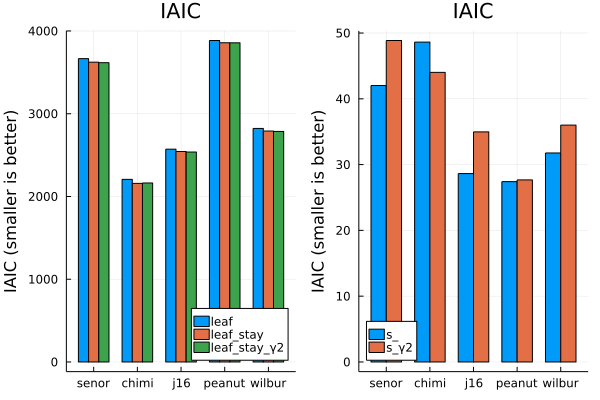

In [39]:
fns = vcat(fns_leaf[1:3])
(results, aics) = load_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][5:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][15:end] for x in fns[2:end]]),
    legend=:bottomleft,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
plot(p1, p2)

# Turn Bias Model

In [144]:
varnames = results[("peanut", "hmm_leaf_stay_turn")].varnames

6-element Vector{String}:
 "βgo"
 "βstay"
 "βleaf"
 "stay_bias"
 "turn_bias"
 "volatility"

In [72]:
betas = mapreduce(permutedims, vcat, [Array(results[(a, "hmm_leaf_stay_turn")].betas') for a in animals])

5×6 Matrix{Float64}:
 12.9664    9.63003  3.62778  5.1188   -0.325772  1.27663
  8.92459   5.81303  2.99452  5.09347  -0.30693   0.183577
 14.0788   11.0042   3.42488  5.30132  -0.102069  0.619236
 13.2474   11.4444   5.2913   3.78438  -0.771122  1.83038
 13.2879   11.4398   8.97508  4.3736   -0.625803  0.757071

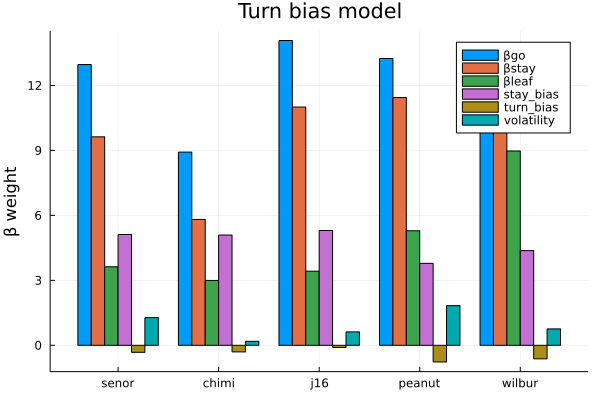

In [83]:
groupedbar(
    x,
    labels=permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames),
    xticks=(1:5, animals),
    ylabel="β weight",
    title="Turn bias model",
    )

In [86]:
[size(results[(a, "hmm_leaf_stay_turn")].x) for a in animals]

5-element Vector{Tuple{Int64, Int64}}:
 (11, 6)
 (16, 6)
 (8, 6)
 (8, 6)
 (8, 6)

In [159]:
x = zeros(5, 16, 9)
x .= NaN
for (a, animal) in enumerate(animals)
    n = size(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x, 1)
    x[a, 1:n, :] .= results[(animal, "hmm_leaf_stay_turn_leafspatial")].x
end
varnames = results[(animal, "hmm_leaf_stay_turn_leafspatial")].varnames

9-element Vector{String}:
 "βgo"
 "βstay"
 "βleaf"
 "stay_bias"
 "turn_bias"
 "leaf_spatial_1"
 "leaf_spatial_2"
 "leaf_spatial_3"
 "volatility"

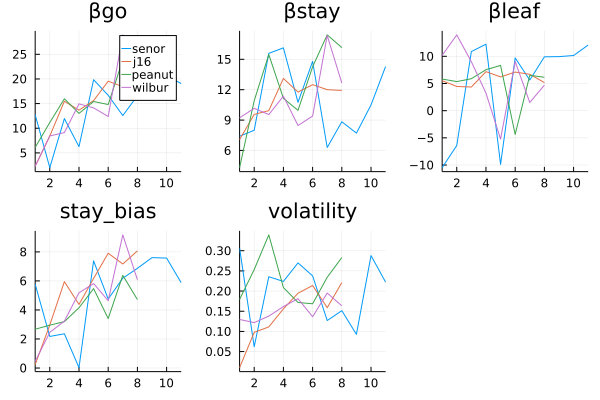

In [160]:
p1 = plot(x[[1,3,4,5], :, 1]',
    labels=permutedims(animals[[1,3,4,5]]),
    title=varnames[1],
)
xlims!(1,11)

p2 = plot(x[[1,3,4,5], :, 2]',
    labels=nothing,
    title=varnames[2],
)
xlims!(1,11)

p3 = plot(x[[1,3,4,5], :, 3]',
    labels=nothing,
    title=varnames[3],
)
xlims!(1,11)

p4 = plot(x[[1,3,4,5], :, 4]',
    labels=nothing,
    title=varnames[4],
)
xlims!(1,11)

p5 = plot(0.5.+0.5.*erf.(x[[1,3,4,5], :, 9]' ./ sqrt(2)),
    labels=nothing,
    title=varnames[9],
)
xlims!(1,11)

plot(p1, p2, p3, p4, p5)

# Leaf Biases

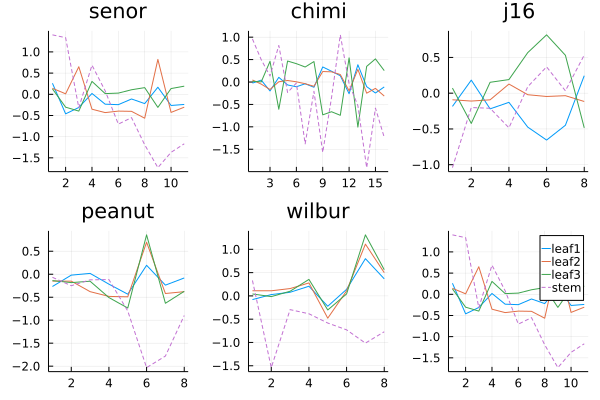

In [57]:
animal = animals[1]
p1 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[2]
p2 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[3]
p3 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[4]
p4 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[5]
p5 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[1]
p6 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"])
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")

plot(p1, p2, p3, p4, p5, p6)

In [65]:
df = load_animal("j16")

,leaf,stem,reward,contingency,date,session,trial,rewscaled,stemchoice
,Int64,String1,Int64,String,Int64,Int64,Int64,Int64,Int64
1,3,B,1,202080502050,20210706,2,0,1,2
2,6,C,0,202080502050,20210706,2,1,-1,3
3,5,C,0,202080502050,20210706,2,2,-1,3
4,2,A,0,202080502050,20210706,2,3,-1,1
5,1,A,0,202080502050,20210706,2,4,-1,1
6,4,B,1,202080502050,20210706,2,5,1,2
7,3,B,0,202080502050,20210706,2,6,-1,2
8,4,B,0,202080502050,20210706,2,7,-1,2
9,6,C,1,202080502050,20210706,2,8,1,3


In [66]:
df

,leaf,stem,reward,contingency,date,session,trial,rewscaled,stemchoice
,Int64,String1,Int64,String,Int64,Int64,Int64,Int64,Int64
1,3,B,1,202080502050,20210706,2,0,1,2
2,6,C,0,202080502050,20210706,2,1,-1,3
3,5,C,0,202080502050,20210706,2,2,-1,3
4,2,A,0,202080502050,20210706,2,3,-1,1
5,1,A,0,202080502050,20210706,2,4,-1,1
6,4,B,1,202080502050,20210706,2,5,1,2
7,3,B,0,202080502050,20210706,2,6,-1,2
8,4,B,0,202080502050,20210706,2,7,-1,2
9,6,C,1,202080502050,20210706,2,8,1,3
